In [1]:
from importlib.metadata import metadata

import pandas as pd

df = pd.read_csv("../data/raw/players_data-2024_2025.csv")

df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
counts = df["Player"].value_counts()

duplicates = counts[counts > 1]
duplicate_players = df[df["Player"].isin(duplicates.index)]
duplicate_players.shape

(304, 267)

In [3]:
duplicate_players[["Player", "Squad", "Comp", "Pos", "Min"]].sort_values("Player")

,Player,Squad,Comp,Pos,Min
1352,Abdukodir Khusanov,Lens,fr Ligue 1,DF,975
1351,Abdukodir Khusanov,Manchester City,eng Premier League,DF,503
189,Adam Aznou,Bayern Munich,de Bundesliga,DF,17
188,Adam Aznou,Valladolid,es La Liga,DF,876
22,Akor Adams,Sevilla,es La Liga,FW,134
...,...,...,...,...,...
536,Walid Cheddira,Napoli,it Serie A,FW,12
358,Warren Bondo,Monza,it Serie A,MF,1618
359,Warren Bondo,Milan,it Serie A,MF,162
620,Woyo Coulibaly,Leicester City,eng Premier League,DF,109


In [4]:
clubs_per_player = duplicate_players.groupby("Player")["Squad"].nunique()
clubs_per_player.value_counts()

Squad
2    152
Name: count, dtype: int64

In [5]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
print(missing_values.head(20))

CS%                      2651
Save%                    2648
PSxG/SoT                 2648
AvgDist                  2646
Cmp%_stats_keeper_adv    2644
Stp%                     2643
90s_stats_keeper_adv     2642
Born_stats_keeper_adv    2642
MP_stats_keeper          2642
PKA                      2642
PKsv                     2642
PKm                      2642
Rk_stats_keeper_adv      2642
Age_stats_keeper         2642
Comp_stats_keeper        2642
W                        2642
Rk_stats_keeper          2642
90s_stats_keeper         2642
GA                       2642
Starts_stats_keeper      2642
dtype: int64


In [6]:
position_counts = df["Pos"].value_counts()
print(position_counts)

Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64


In [7]:
print(missing_values.tail(30))

Won%                          222
On-Off                         22
Cmp%                           19
Age                             8
Born_stats_shooting             8
Age_stats_passing               8
Age_stats_shooting              8
Born                            8
Age_stats_gca                   8
Born_stats_gca                  8
Born_stats_passing              8
Born_stats_defense              8
Age_stats_possession            8
Born_stats_possession           8
Born_stats_passing_types        8
Age_stats_passing_types         8
Born_stats_playing_time         8
Age_stats_playing_time          8
Age_stats_misc                  8
Born_stats_misc                 8
Age_stats_defense               8
Nation_stats_passing            7
Nation_stats_possession         7
Nation_stats_defense            7
Nation_stats_passing_types      7
Nation_stats_gca                7
Nation_stats_shooting           7
Nation                          7
Nation_stats_misc               7
Nation_stats_p

In [8]:
missing_age = df[df["Age"].isnull()]
missing_age_info = missing_age[["Player", "Squad", "Comp", "Pos", "Age", "Born", "Nation", "Min"]]
print(missing_age_info)

                   Player           Squad                Comp    Pos  Age  \
100         Olabade Aluko  Leicester City  eng Premier League     DF  NaN   
273        Hannes Behrens      Hoffenheim       de Bundesliga     DF  NaN   
663   Pape Daouda Diongue      Strasbourg          fr Ligue 1  MF,FW  NaN   
862            Jake Evans  Leicester City  eng Premier League     FW  NaN   
1518            Fer López      Celta Vigo          es La Liga  FW,MF  NaN   
1603          Mateus Mane          Wolves  eng Premier League     MF  NaN   
1769        Max Moerstedt      Hoffenheim       de Bundesliga     FW  NaN   
1778         Jeremy Monga  Leicester City  eng Premier League  FW,MF  NaN   

      Born  Nation  Min  
100    NaN     NaN    2  
273    NaN  de GER   29  
663    NaN  sn SEN   78  
862    NaN     NaN   24  
1518   NaN     NaN  671  
1603   NaN     NaN    2  
1769   NaN  de GER  451  
1778   NaN     NaN  112  


In [9]:
missing_nation = df[df["Nation"].isnull()]
missing_nation[
    ["Player", "Squad", "Comp", "Pos", "Age", "Born", "Nation", "Min"]
]
print(missing_nation)

        Rk          Player Nation    Pos           Squad                Comp  \
100    101   Olabade Aluko    NaN     DF  Leicester City  eng Premier League   
862    863      Jake Evans    NaN     FW  Leicester City  eng Premier League   
1320  1321  Atakan Karazor    NaN     MF       Stuttgart       de Bundesliga   
1518  1519       Fer López    NaN  FW,MF      Celta Vigo          es La Liga   
1603  1604     Mateus Mane    NaN     MF          Wolves  eng Premier League   
1778  1779    Jeremy Monga    NaN  FW,MF  Leicester City  eng Premier League   
1917  1918  Plamedi Nsingi    NaN     MF          Nantes          fr Ligue 1   

       Age    Born  MP  Starts  ...  Att (GK)  Thr  Launch%  AvgLen  Opp  Stp  \
100    NaN     NaN   1       0  ...       NaN  NaN      NaN     NaN  NaN  NaN   
862    NaN     NaN   4       0  ...       NaN  NaN      NaN     NaN  NaN  NaN   
1320  27.0  1996.0  32      31  ...       NaN  NaN      NaN     NaN  NaN  NaN   
1518   NaN     NaN  17       7  ...

In [10]:
missing_age_and_nation = df[(df["Age"].isnull()) & (df["Nation"].isnull())]
missing_age_and_nation[["Player", "Age", "Born", "Nation"]]

,Player,Age,Born,Nation
100,Olabade Aluko,NaN,NaN,NaN
862,Jake Evans,NaN,NaN,NaN
1518,Fer López,NaN,NaN,NaN
1603,Mateus Mane,NaN,NaN,NaN
1778,Jeremy Monga,NaN,NaN,NaN


In [11]:
for column in df.columns:
    print(column)

Rk
Player
Nation
Pos
Squad
Comp
Age
Born
MP
Starts
Min
90s
Gls
Ast
G+A
G-PK
PK
PKatt
CrdY
CrdR
xG
npxG
xAG
npxG+xAG
PrgC
PrgP
PrgR
G+A-PK
xG+xAG
Rk_stats_shooting
Nation_stats_shooting
Pos_stats_shooting
Comp_stats_shooting
Age_stats_shooting
Born_stats_shooting
90s_stats_shooting
Gls_stats_shooting
Sh
SoT
SoT%
Sh/90
SoT/90
G/Sh
G/SoT
Dist
FK
PK_stats_shooting
PKatt_stats_shooting
xG_stats_shooting
npxG_stats_shooting
npxG/Sh
G-xG
np:G-xG
Rk_stats_passing
Nation_stats_passing
Pos_stats_passing
Comp_stats_passing
Age_stats_passing
Born_stats_passing
90s_stats_passing
Cmp
Att
Cmp%
TotDist
PrgDist
Ast_stats_passing
xAG_stats_passing
xA
A-xAG
KP
1/3
PPA
CrsPA
PrgP_stats_passing
Rk_stats_passing_types
Nation_stats_passing_types
Pos_stats_passing_types
Comp_stats_passing_types
Age_stats_passing_types
Born_stats_passing_types
90s_stats_passing_types
Att_stats_passing_types
Live
Dead
FK_stats_passing_types
TB
Sw
Crs
TI
CK
In
Out
Str
Cmp_stats_passing_types
Off
Blocks
Rk_stats_gca
Nation_stats_

In [12]:
outfield_df = df[df["Pos"] != "GK"]
goalkeeper_df = df[df["Pos"] == "GK"]
print(outfield_df)
print(goalkeeper_df)

        Rk             Player   Nation    Pos        Squad  \
0        1         Max Aarons  eng ENG     DF  Bournemouth   
1        2         Max Aarons  eng ENG  DF,MF     Valencia   
2        3     Rodrigo Abajas   es ESP     DF     Valencia   
3        4     James Abankwah   ie IRL  DF,MF      Udinese   
4        5  Keyliane Abdallah   fr FRA     FW    Marseille   
...    ...                ...      ...    ...          ...   
2849  2850       Edhy Zuliani   fr FRA     DF     Toulouse   
2850  2851   Szymon Żurkowski   pl POL     MF       Empoli   
2851  2852    Martin Ødegaard   no NOR     MF      Arsenal   
2852  2853        Milan Đurić   ba BIH     FW        Monza   
2853  2854        Milan Đurić   ba BIH     FW        Parma   

                    Comp   Age    Born  MP  Starts  ...  Att (GK)  Thr  \
0     eng Premier League  24.0  2000.0   3       1  ...       NaN  NaN   
1             es La Liga  24.0  2000.0   4       1  ...       NaN  NaN   
2             es La Liga  21.0  2

In [13]:
outfield_df["Min"].describe()

count    2642.000000
mean     1189.457986
std       942.184698
min         1.000000
25%       313.000000
50%      1045.000000
75%      1952.000000
max      3420.000000
Name: Min, dtype: float64

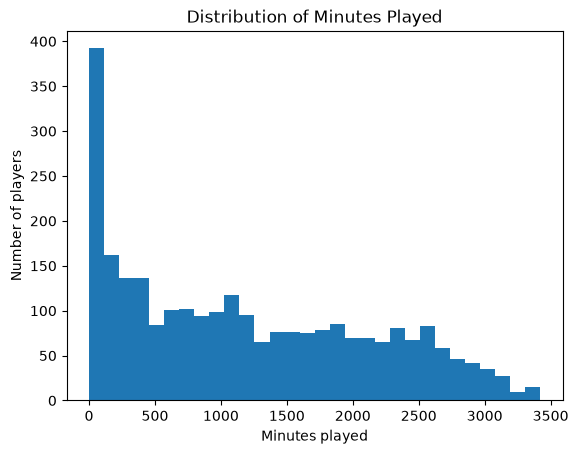

In [14]:
import matplotlib.pyplot as plt

plt.hist(outfield_df["Min"], bins = 30)
plt.xlabel("Minutes played")
plt.ylabel("Number of players")
plt.title("Distribution of Minutes Played")
plt.show()

In [15]:
under_90 = outfield_df[outfield_df["Min"] < 90]
under_180 = outfield_df[outfield_df["Min"] < 180]
under_450 = outfield_df[outfield_df["Min"] < 450]
under_900 = outfield_df[outfield_df["Min"] < 900]
print("Under 90:", len(under_90))
print("Under 180:", len(under_180))
print("Under 450:", len(under_450))
print("Under 900:", len(under_900))

Under 90: 345
Under 180: 496
Under 450: 815
Under 900: 1192


In [16]:
basic_features = [
    "Player",
    "Nation",
    "Pos",
    "Squad",
    "Comp",
    "Age",
    "Min"
]

attacking_features = [
    "Gls",
    "Ast",
    "xG",
    "xAG",
    "Sh",
    "SoT"
]

passing_features = [
    "Cmp%",
    "xA",
    "KP",
    "PrgP",
    "PPA"
]

possession_features = [
    "Touches",
    "Succ",
    "Succ%",
    "PrgC",
    "CPA",
    "Mis",
    "Dis"
]

defensive_features = [
    "Tkl",
    "TklW",
    "Int",
    "Blocks_stats_defense",
    "Clr",
    "Err"
]

misc_features = [
    "Recov",
    "Won",
    "Lost_stats_misc",
    "Won%"
]

In [17]:
selected_features = (
    basic_features
    + attacking_features
    + passing_features
    + possession_features
    + defensive_features
    + misc_features
)

outfield_selected = outfield_df[selected_features].copy()
outfield_selected.shape
outfield_selected.head()

,Player,Nation,Pos,Squad,Comp,Age,Min,Gls,Ast,xG,...,Tkl,TklW,Int,Blocks_stats_defense,Clr,Err,Recov,Won,Lost_stats_misc,Won%
0,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,86,0,0,0.0,...,2,2,1,3,0,0,7,0,0,NaN
1,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,120,0,0,0.0,...,4,4,0,1,3,0,7,2,1,66.7
2,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,65,0,0,0.1,...,3,2,1,1,0,0,2,0,1,0.0
3,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,88,0,0,0.1,...,4,2,1,2,3,0,7,2,2,50.0
4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,3,0,0,0.0,...,1,1,0,0,0,0,0,0,0,NaN


In [18]:
metadata_features = [
    "Player",
    "Nation",
    "Pos",
    "Squad",
    "Comp",
    "Age"
]

sum_features = [
    "Min",
    "Gls",
    "Ast",
    "xG",
    "xAG",
    "Sh",
    "SoT",
    "xA",
    "KP",
    "PrgP",
    "PPA",
    "Touches",
    "Succ",
    "PrgC",
    "CPA",
    "Mis",
    "Dis",
    "Tkl",
    "TklW",
    "Int",
    "Blocks_stats_defense",
    "Clr",
    "Err",
    "Recov",
    "Won",
    "Lost_stats_misc"
]

percentage_features = [
    "Cmp%",
    "Succ%",
    "Won%"
]

aggregation_helpers = [
    "Cmp",
    "Att",
    "Att_stats_possession"
]

In [19]:
selected_features = (
    basic_features
    + attacking_features
    + passing_features
    + possession_features
    + defensive_features
    + misc_features
    + aggregation_helpers
)

outfield_selected = outfield_df[selected_features].copy()
outfield_selected.shape

(2642, 38)

In [20]:
import numpy as np

def safe_percentage(numerator, denominator):
    if denominator == 0:
        return np.nan
    return (numerator / denominator) * 100


In [21]:
def aggregate_player(group):
    result = {}

    # Main row = club where the player played the most minutes
    main_row = group.loc[group["Min"].idxmax()]

    # Metadata
    result["Player"] = group["Player"].iloc[0]
    result["Nation"] = group["Nation"].iloc[0]
    result["Age"] = group["Age"].iloc[0]

    # Primary position from main club
    result["Pos"] = main_row["Pos"].split(",")[0]

    # Keep all clubs as metadata
    result["Squad"] = " / ".join(group["Squad"].unique())

    # Main competition
    result["Comp"] = main_row["Comp"]

    # Additive statistics
    for feature in sum_features:
        result[feature] = group[feature].sum()

    # Passing %
    total_cmp = group["Cmp"].sum()
    total_att = group["Att"].sum()
    result["Cmp%"] = safe_percentage(total_cmp, total_att)

    # Take-on %
    total_succ = group["Succ"].sum()
    total_takeon_att = group["Att_stats_possession"].sum()
    result["Succ%"] = safe_percentage(total_succ, total_takeon_att)

    # Aerial duel %
    total_won = group["Won"].sum()
    total_lost = group["Lost_stats_misc"].sum()
    result["Won%"] = safe_percentage(
        total_won,
        total_won + total_lost
    )

    return result


In [22]:
player_groups = outfield_selected.groupby("Player")

aggregated_players = []

for player, group in player_groups:
    aggregated_players.append(aggregate_player(group))

aggregated_df = pd.DataFrame(aggregated_players)
print(aggregated_df.shape)
aggregated_df.head()

(2494, 35)


,Player,Nation,Age,Pos,Squad,Comp,Min,Gls,Ast,xG,...,Int,Blocks_stats_defense,Clr,Err,Recov,Won,Lost_stats_misc,Cmp%,Succ%,Won%
0,Aaron Ciammaglichella,it ITA,19.0,MF,Torino,it Serie A,1,0,0,0.0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,Aaron Cresswell,eng ENG,34.0,DF,West Ham,eng Premier League,824,0,0,0.2,...,8,9,37,0,36,7,7,82.622951,50.000000,50.000000
2,Aaron Malouda,fr FRA,18.0,FW,Lille,fr Ligue 1,2,0,0,0.0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
3,Aaron Wan-Bissaka,eng ENG,26.0,DF,West Ham,eng Premier League,3154,2,5,1.2,...,66,37,125,0,174,22,33,81.101928,52.459016,40.000000
4,Aarón Martín,es ESP,27.0,DF,Genoa,it Serie A,3085,0,8,0.9,...,19,33,73,1,146,20,33,72.462908,44.444444,37.735849


In [23]:
print("Unique players:", outfield_selected["Player"].nunique())
print("Aggregated rows:", aggregated_df.shape[0])
print("Duplicates:", aggregated_df["Player"].duplicated().sum())

Unique players: 2494
Aggregated rows: 2494
Duplicates: 0


In [24]:
aggregated_df.info()
aggregated_df.head(10)
aggregated_df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 2494 entries, 0 to 2493
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Player                2494 non-null   str    
 1   Nation                2487 non-null   str    
 2   Age                   2486 non-null   float64
 3   Pos                   2494 non-null   str    
 4   Squad                 2494 non-null   str    
 5   Comp                  2494 non-null   str    
 6   Min                   2494 non-null   int64  
 7   Gls                   2494 non-null   int64  
 8   Ast                   2494 non-null   int64  
 9   xG                    2494 non-null   float64
 10  xAG                   2494 non-null   float64
 11  Sh                    2494 non-null   int64  
 12  SoT                   2494 non-null   int64  
 13  xA                    2494 non-null   float64
 14  KP                    2494 non-null   int64  
 15  PrgP                  2494 non-n

Succ%                   243
Won%                    149
Cmp%                     17
Age                       8
Nation                    7
Player                    0
Pos                       0
Gls                       0
Squad                     0
Comp                      0
Min                       0
Sh                        0
SoT                       0
xA                        0
KP                        0
PrgP                      0
Ast                       0
xG                        0
xAG                       0
Succ                      0
Touches                   0
PPA                       0
PrgC                      0
Tkl                       0
CPA                       0
Mis                       0
Dis                       0
Blocks_stats_defense      0
Int                       0
TklW                      0
Clr                       0
Won                       0
Recov                     0
Err                       0
Lost_stats_misc           0
dtype: int64

In [25]:
missing_percentages= aggregated_df[
    aggregated_df[["Cmp%", "Succ%", "Won%"]].isna().any(axis=1)
]

missing_percentages[
    ["Player", "Min", "Cmp%", "Succ", "Succ%", "Won", "Lost_stats_misc", "Won%"]
].head(30)

,Player,Min,Cmp%,Succ,Succ%,Won,Lost_stats_misc,Won%
0,Aaron Ciammaglichella,1,NaN,0,NaN,0,0,NaN
2,Aaron Malouda,2,NaN,0,NaN,0,0,NaN
17,Abdoulie Ceesay,60,57.142857,0,NaN,0,6,0.000000
25,Aboubacar Bassinga,4,50.000000,0,NaN,0,0,NaN
48,Adrian Niño,12,NaN,0,NaN,0,1,0.000000
55,Adryelson,1,33.333333,0,NaN,1,0,100.000000
56,Adu Ares,19,55.555556,0,0.0,0,0,NaN
70,Alberto Cerri,87,65.217391,0,NaN,4,4,50.000000
73,Alberto Manzoni,6,91.666667,0,NaN,1,0,100.000000
74,Alberto Marí,7,50.000000,0,NaN,0,0,NaN


In [28]:
print("Missing Succ%:", aggregated_df["Succ%"].isna().sum())

print(
    "Missing Succ% with Succ = 0:",
    (
        aggregated_df["Succ%"].isna()
        & (aggregated_df["Succ"] == 0)
    ).sum()
)

print("\nMissing Won%:", aggregated_df["Won%"].isna().sum())
print(
    "Missing Won% with Won = 0 and Lost = 0:",
    (
        aggregated_df["Won%"].isna()
        & (aggregated_df["Won"] == 0)
        & (aggregated_df["Lost_stats_misc"] == 0)
    ).sum()
)

Missing Succ%: 243
Missing Succ% with Succ = 0: 243

Missing Won%: 149
Missing Won% with Won = 0 and Lost = 0: 149


In [29]:
missing_succ_players = set(
    aggregated_df.loc[
        aggregated_df["Succ%"].isna(),
        "Player"
    ]
)

check_succ = outfield_selected[
    outfield_selected["Player"].isin(missing_succ_players)
].groupby("Player").agg(
    Succ=("Succ", "sum"),
    Att=("Att_stats_possession", "sum")
)

print(check_succ.head(20))
print("\nPlayers with 0 attempts:", (check_succ["Att"] == 0).sum())
print("Total players with missing Succ%:", len(check_succ))

                        Succ  Att
Player                           
Aaron Ciammaglichella      0    0
Aaron Malouda              0    0
Abdoulie Ceesay            0    0
Aboubacar Bassinga         0    0
Adrian Niño                0    0
Adryelson                  0    0
Alberto Cerri              0    0
Alberto Manzoni            0    0
Alberto Marí               0    0
Alejandro Rodriguez        0    0
Alessandro Circati         0    0
Alessandro Florenzi        0    0
Alessandro Gabrielloni     0    0
Alfie Dorrington           0    0
Alfie Pond                 0    0
Ali Jasim                  0    0
Alois Confais              0    0
Alphadjo Cissè             0    0
Ameen Al-Dakhil            0    0
Andreas Christensen        0    0

Players with 0 attempts: 243
Total players with missing Succ%: 243


In [30]:
missing_cmp_players = set(
    aggregated_df.loc[
        aggregated_df["Cmp%"].isna(),
        "Player"
    ]
)

check_cmp = outfield_selected[
    outfield_selected["Player"].isin(missing_cmp_players)
].groupby("Player").agg(
    Cmp=("Cmp", "sum"),
    Att=("Att", "sum")
)

print(check_cmp)

print(
    "\nPlayers with 0 pass attempts:",
    (check_cmp["Att"] == 0).sum()
)

print(
    "Total players with missing Cmp%:",
    len(check_cmp)
)

                       Cmp  Att
Player                         
Aaron Ciammaglichella    0    0
Aaron Malouda            0    0
Adrian Niño              0    0
Anthony Briançon         0    0
Ayanda Sishuba           0    0
Boubacar Traoré          0    0
Daniel Yáñez             0    0
Faik Sakar               0    0
Faris Pemi Moumbagna     0    0
Jay Stansfield           0    0
Kacper Koscierski        0    0
Kaelan Casey             0    0
Michael Golding          0    0
Nathan Butler-Oyedeji    0    0
Remy Rees-Dottin         0    0
Saba Sazonov             0    0
Shumaira Mheuka          0    0

Players with 0 pass attempts: 17
Total players with missing Cmp%: 17


In [32]:
missing_metadata = aggregated_df[
    aggregated_df["Age"].isna() |
    aggregated_df["Nation"].isna()
][
    ["Player", "Nation", "Age", "Pos", "Squad", "Comp", "Min"]
]

missing_metadata.sort_values("Min", ascending=False)

,Player,Nation,Age,Pos,Squad,Comp,Min
270,Atakan Karazor,NaN,27.0,MF,Stuttgart,de Bundesliga,2618
743,Fer López,NaN,NaN,FW,Celta Vigo,es La Liga,671
1640,Max Moerstedt,de GER,NaN,FW,Hoffenheim,de Bundesliga,451
1091,Jeremy Monga,NaN,NaN,FW,Leicester City,eng Premier League,112
1897,Pape Daouda Diongue,sn SEN,NaN,MF,Strasbourg,fr Ligue 1,78
882,Hannes Behrens,de GER,NaN,DF,Hoffenheim,de Bundesliga,29
1016,Jake Evans,NaN,NaN,FW,Leicester City,eng Premier League,24
1967,Plamedi Nsingi,NaN,23.0,MF,Nantes,fr Ligue 1,16
1585,Mateus Mane,NaN,NaN,MF,Wolves,eng Premier League,2
1851,Olabade Aluko,NaN,NaN,DF,Leicester City,eng Premier League,2


Market Value Data

In [33]:
players_tm = pd.read_csv("../data/raw/players.csv")
valuations = pd.read_csv("../data/raw/player_valuations.csv")

print("Players:", players_tm.shape)
print("Valuations:", valuations.shape)

print("\nPlayers columns:")
print(players_tm.columns.tolist())

print("\nValuations columns:")
print(valuations.columns.tolist())

display(players_tm.head())
display(valuations.head())

Players: (50149, 26)
Valuations: (656301, 6)

Players columns:
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Valuations columns:
['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398,IT1


In [35]:
valuations["date"] = pd.to_datetime(valuations["date"])

print(valuations["date"].min())
print(valuations["date"].max())

cutoff_date = pd.Timestamp("2025-06-30")

valuations_2425 = valuations[
    valuations["date"] <= cutoff_date
].copy()

season_start = pd.Timestamp("2024-07-01")
season_end = pd.Timestamp("2025-06-30")

valuations_2425 = valuations[
    (valuations["date"] >= season_start) &
    (valuations["date"] <= season_end)
].copy()

print(valuations_2425.shape)
print(valuations_2425["date"].min())
print(valuations_2425["date"].max())

latest_values_2425 = (
    valuations_2425
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    [["player_id", "date", "market_value_in_eur"]]
)

print(latest_values_2425.shape)
latest_values_2425.head()

market_values_2425 = latest_values_2425.merge(
    players_tm[["player_id", "name"]],
    on="player_id",
    how="left",
)

market_values_2425 = market_values_2425[
    ["player_id", "name", "date", "market_value_in_eur"]
]

market_values_2425.head()

print("Players with 24/25 market value:", len(market_values_2425))

market_values_2425[
    "market_value_in_eur"
].describe()

2000-01-20 00:00:00
2026-06-12 00:00:00
(43444, 6)
2024-07-01 00:00:00
2025-06-30 00:00:00
(18050, 3)
Players with 24/25 market value: 18050


count    1.805000e+04
mean     2.789368e+06
std      8.218381e+06
min      1.000000e+04
25%      2.500000e+05
50%      5.500000e+05
75%      1.800000e+06
max      2.000000e+08
Name: market_value_in_eur, dtype: float64

In [37]:
exact_matches = aggregated_df.merge(
    market_values_2425,
    left_on="Player",
    right_on="name",
    how="left"
)

print("Total FBref players:", len(exact_matches))
print(
    "Exact matches:",
    exact_matches["market_value_in_eur"].notna().sum()
)

match_rate = (
    exact_matches["market_value_in_eur"].notna().mean() * 100
)

print(f"Match rate: {match_rate:.2f}%")

unmatched = exact_matches[
    exact_matches["market_value_in_eur"].isna()
]

unmatched[
    ["Player", "Squad", "Comp", "Age", "Min"]
].sort_values(
    "Min",
    ascending=False
).head(30)

Total FBref players: 2531
Exact matches: 2004
Match rate: 79.18%


,Player,Squad,Comp,Age,Min
1874,Obite N'Dicka,Roma,it Serie A,24.0,3420
1668,Max Kilman,West Ham,eng Premier League,27.0,3348
1219,Joško Gvardiol,Manchester City,eng Premier League,22.0,3277
225,Antonio Raillo,Mallorca,es La Liga,32.0,3207
975,Illia Zabarnyi,Bournemouth,eng Premier League,21.0,3109
407,Carlos Vicente,Alavés,es La Liga,25.0,3092
615,Dodi Lukebakio,Sevilla,es La Liga,26.0,3092
414,Catena,Osasuna,es La Liga,29.0,3074
175,Andrei Ratiu,Rayo Vallecano,es La Liga,26.0,3065
955,Idrissa Gana Gueye,Everton,eng Premier League,34.0,3063


In [39]:
print("aggregated_df rows:", len(aggregated_df))
print("market_values rows:", len(market_values_2425))

print(
    "Duplicate names in market values:",
    market_values_2425["name"].duplicated().sum()
)

duplicate_names = market_values_2425[
    market_values_2425["name"].duplicated(keep=False)
].sort_values("name")

display(duplicate_names.head(30))

tm_name_counts = (
    market_values_2425
    .groupby("name")
    .size()
)

ambiguous_names = tm_name_counts[
    tm_name_counts > 1
].index

ambiguous_fbref = aggregated_df[
    aggregated_df["Player"].isin(ambiguous_names)
]

print(
    "FBref players with ambiguous exact name:",
    len(ambiguous_fbref)
)

display(
    ambiguous_fbref[
        ["Player", "Squad", "Comp", "Age", "Min"]
    ].sort_values("Player")
)

aggregated_df rows: 2494
market_values rows: 18050
Duplicate names in market values: 228


,player_id,name,date,market_value_in_eur
3268,364405,Adama Traoré,2025-05-28,3500000
6783,70209,Adama Traoré,2025-06-03,100000
4517,204103,Adama Traoré,2025-05-30,9000000
5532,943969,Agustín Palavecino,2025-06-02,275000
1556,610590,Agustín Palavecino,2025-05-26,4000000
8976,503343,Alan Franco,2025-06-06,4500000
9714,400960,Alan Franco,2025-06-06,4000000
9367,229736,Alisson,2025-06-06,1800000
4634,105470,Alisson,2025-05-30,20000000
11184,1083070,Alisson,2025-06-10,9000000


FBref players with ambiguous exact name: 28


,Player,Squad,Comp,Age,Min
39,Adama Traoré,Fulham,eng Premier League,28.0,1772
182,André Gomes,Lille,fr Ligue 1,31.0,1276
183,André Silva,Werder Bremen / RB Leipzig,de Bundesliga,28.0,507
225,Antonio Sánchez,Mallorca,es La Liga,27.0,1395
227,Antony,Manchester Utd / Betis,es La Liga,24.0,1503
301,Ben Davies,Tottenham,eng Premier League,31.0,1331
326,Bernardo,Bochum,de Bundesliga,29.0,1782
359,Brenner,Udinese,it Serie A,24.0,386
423,Chiquinho,Wolves / Mallorca,es La Liga,24.0,153
516,Danilo,Nott'ham Forest / Juventus,it Serie A,23.0,856


In [40]:
latest_values_2425 = (
    valuations_2425
    .sort_values("date")
    .groupby("player_id")
    .tail(1)
    [[
        "player_id",
        "date",
        "market_value_in_eur",
        "current_club_name"
    ]]
)

market_values_2425 = latest_values_2425.merge(
    players_tm[
        ["player_id", "name", "date_of_birth", "position"]
    ],
    on="player_id",
    how="left"
)

market_values_2425.head()

market_values_2425[
    market_values_2425["name"] == "Adama Traoré"
][
    [
        "player_id",
        "name",
        "current_club_name",
        "date_of_birth",
        "market_value_in_eur"
    ]
]

,player_id,name,current_club_name,date_of_birth,market_value_in_eur
3268,364405,Adama Traoré,Ferencvárosi TC,1995-06-05 00:00:00,3500000
4517,204103,Adama Traoré,Fulham FC,1996-01-25 00:00:00,9000000
6783,70209,Adama Traoré,Melbourne Victory,1990-02-03 00:00:00,100000


In [42]:
tm_name_counts = market_values_2425["name"].value_counts()

unique_tm_names = tm_name_counts[
    tm_name_counts == 1
].index

unique_market_values = market_values_2425[
    market_values_2425["name"].isin(unique_tm_names)
].copy()

print("Unique TM names:", len(unique_market_values))

Unique TM names: 17640


In [43]:
matched_exact = aggregated_df.merge(
    unique_market_values,
    left_on="Player",
    right_on="name",
    how="left"
)

print("Rows:", len(matched_exact))

print(
    "Safe exact matches:",
    matched_exact["player_id"].notna().sum()
)

print(
    "Still unmatched:",
    matched_exact["player_id"].isna().sum()
)

print(
    f"Safe match rate: "
    f"{matched_exact['player_id'].notna().mean() * 100:.2f}%"
)

assert len(matched_exact) == len(aggregated_df)
assert matched_exact["Player"].duplicated().sum() == 0

Rows: 2494
Safe exact matches: 1939
Still unmatched: 555
Safe match rate: 77.75%


In [44]:
import unicodedata
import re

def normalize_name(name):
    if pd.isna(name):
        return ""

    name = str(name).lower().strip()

    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    name = re.sub(r"[^\w\s]", "", name)

    name = re.sub(r"\s+", " ", name)
    return name

test_names = [
    "Joško Gvardiol",
    "Dodi Lukébakio",
    "João Pedro",
    "  Kylian   Mbappé  "
]

for name in test_names:
    print(name, "->", normalize_name(name))

Joško Gvardiol -> josko gvardiol
Dodi Lukébakio -> dodi lukebakio
João Pedro -> joao pedro
  Kylian   Mbappé   -> kylian mbappe


In [45]:
unmatched["normalized_name"] = (
    unmatched["Player"].apply(normalize_name)
)

market_values_2425["normalized_name"] = (
    market_values_2425["name"].apply(normalize_name)
)

normalized_counts = (
    market_values_2425["normalized_name"]
    .value_counts()
)

unique_normalized_names = normalized_counts[
    normalized_counts == 1
].index

unique_normalized_tm = market_values_2425[
    market_values_2425["normalized_name"].isin(
        unique_normalized_names
    )
].copy()

normalized_matches = unmatched[
    ["Player", "normalized_name"]
].merge(
    unique_normalized_tm[
        [
            "normalized_name",
            "player_id",
            "name",
            "current_club_name",
            "date_of_birth",
            "market_value_in_eur",
            "date"
        ]
    ],
    on="normalized_name",
    how="left"
)
new_matches = normalized_matches[
    normalized_matches["player_id"].notna()
]

print("Previously unmatched:", len(unmatched))
print("New normalized matches:", len(new_matches))
print(
    "Still unmatched:",
    normalized_matches["player_id"].isna().sum()
)

display(
    new_matches[
        [
            "Player",
            "name",
            "current_club_name",
            "market_value_in_eur"
        ]
    ].head(30)
)

Previously unmatched: 527
New normalized matches: 133
Still unmatched: 394


,Player,name,current_club_name,market_value_in_eur
6,Adam Hložek,Adam Hlozek,TSG 1899 Hoffenheim,18000000.0
7,Adam Marušić,Adam Marusic,SS Lazio,3500000.0
10,Adrian Bernabe,Adrián Bernabé,Parma Calcio 1913,15000000.0
12,Adrien Tameze,Adrien Tamèze,Torino FC,2000000.0
19,Alberto costa,Alberto Costa,Juventus FC,10000000.0
21,Alejandro Rodriguez,Alejandro Rodríguez,Deportivo Cali,1000000.0
22,Alejo Véliz,Alejo Veliz,RCD Espanyol Barcelona,2500000.0
25,Alex Baena,Álex Baena,Villarreal CF,55000000.0
26,Alex Sola,Álex Sola,Getafe CF,2500000.0
39,Andrei Ratiu,Andrei Rațiu,Rayo Vallecano,12000000.0


In [46]:
display(
    new_matches[
        [
            "Player",
            "name",
            "current_club_name",
            "market_value_in_eur"
        ]
    ].sort_values("Player").head(50)
)

,Player,name,current_club_name,market_value_in_eur
6,Adam Hložek,Adam Hlozek,TSG 1899 Hoffenheim,18000000.0
7,Adam Marušić,Adam Marusic,SS Lazio,3500000.0
10,Adrian Bernabe,Adrián Bernabé,Parma Calcio 1913,15000000.0
12,Adrien Tameze,Adrien Tamèze,Torino FC,2000000.0
19,Alberto costa,Alberto Costa,Juventus FC,10000000.0
21,Alejandro Rodriguez,Alejandro Rodríguez,Deportivo Cali,1000000.0
22,Alejo Véliz,Alejo Veliz,RCD Espanyol Barcelona,2500000.0
25,Alex Baena,Álex Baena,Villarreal CF,55000000.0
26,Alex Sola,Álex Sola,Getafe CF,2500000.0
39,Andrei Ratiu,Andrei Rațiu,Rayo Vallecano,12000000.0


In [54]:
from rapidfuzz import process, fuzz

# Names of players that are still unmatched after normalized matching
remaining_players = set(
    normalized_matches.loc[
        normalized_matches["player_id"].isna(),
        "Player"
    ]
)

# Go back to the original aggregated dataset
# so we don't carry columns from previous merges
still_unmatched = aggregated_df[
    aggregated_df["Player"].isin(remaining_players)
].copy()

# Normalize FBref names again
still_unmatched["normalized_name"] = (
    still_unmatched["Player"].apply(normalize_name)
)

print("Still unmatched before fuzzy matching:", len(still_unmatched))


# All normalized Transfermarkt names
tm_names = (
    market_values_2425["normalized_name"]
    .dropna()
    .unique()
    .tolist()
)


def find_best_match(name):
    match = process.extractOne(
        name,
        tm_names,
        scorer=fuzz.ratio
    )

    if match is None:
        return pd.Series([None, 0])

    return pd.Series([match[0], match[1]])


# Find best Transfermarkt name for every unmatched FBref player
still_unmatched[
    ["best_tm_name", "name_score"]
] = still_unmatched["normalized_name"].apply(
    find_best_match
)


# Score distribution
display(
    still_unmatched["name_score"].describe()
)


# Best fuzzy matches
display(
    still_unmatched[
        [
            "Player",
            "normalized_name",
            "best_tm_name",
            "name_score"
        ]
    ]
    .sort_values(
        "name_score",
        ascending=False
    )
    .head(50)
)

Still unmatched before fuzzy matching: 394


count    394.000000
mean      78.077874
std        9.370886
min       58.333333
25%       70.967742
50%       77.419355
75%       84.615385
max      100.000000
Name: name_score, dtype: float64

,Player,normalized_name,best_tm_name,name_score
1343,Ladislav Krejčí,ladislav krejci,ladislav krejci,100.000000
2040,Roberto Férnandez,roberto fernandez,roberto fernandez,100.000000
1096,Jesus Rodríguez,jesus rodriguez,jesus rodriguez,100.000000
1072,Jean-Daniel Akpa-Akpro,jeandaniel akpaakpro,jeandaniel akpa akpro,97.560976
589,Dimitris Giannoulis,dimitris giannoulis,dimitrios giannoulis,97.435897
241,Armel Bella Kotchap,armel bella kotchap,armel bellakotchap,97.297297
1703,Mohamed Abdelmoneim,mohamed abdelmoneim,mohamed abdelmonem,97.297297
1068,Jean Mattéo Bahoya,jean matteo bahoya,jeanmatteo bahoya,97.142857
1513,Marc-Oliver Kempf,marcoliver kempf,marc oliver kempf,96.969697
1355,Lautaro Gianetti,lautaro gianetti,lautaro giannetti,96.969697


In [55]:
fuzzy_candidates = still_unmatched.merge(
    market_values_2425[
        [
            "normalized_name",
            "player_id",
            "name",
            "current_club_name",
            "date_of_birth",
            "market_value_in_eur"
        ]
    ],
    left_on="best_tm_name",
    right_on="normalized_name",
    how="left",
    suffixes=("_fbref", "_tm")
)

print("Unmatched players:", len(still_unmatched))
print("Candidate rows:", len(fuzzy_candidates))

display(
    fuzzy_candidates[
        [
            "Player",
            "name",
            "name_score",
            "Squad",
            "current_club_name",
            "Age",
            "date_of_birth",
            "market_value_in_eur"
        ]
    ]
    .sort_values(
        ["name_score", "Player"],
        ascending=[False, True]
    )
    .head(50)
)

Unmatched players: 394
Candidate rows: 411


,Player,name,name_score,Squad,current_club_name,Age,date_of_birth,market_value_in_eur
188,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Puebla FC,18.0,1993-05-21 00:00:00,500000
189,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Real Betis Balompié,18.0,2005-11-21 00:00:00,30000000
237,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,Girona FC,25.0,1999-04-20 00:00:00,12000000
238,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,FK Teplice,25.0,1992-07-05 00:00:00,175000
333,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Club Cerro Porteño,22.0,1988-03-29 00:00:00,250000
334,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Akron Tolyatti,22.0,1999-07-12 00:00:00,1200000
335,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Dynamo Moscow,22.0,2000-06-07 00:00:00,3500000
336,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,RCD Espanyol Barcelona,22.0,2002-07-03 00:00:00,6000000
184,Jean-Daniel Akpa-Akpro,Jean-Daniel Akpa Akpro,97.560976,Monza,AC Monza,31.0,1992-10-11 00:00:00,500000
95,Dimitris Giannoulis,Dimitrios Giannoulis,97.435897,Augsburg,FC Augsburg,28.0,1995-10-17 00:00:00,3000000


In [56]:
def normalize_club(name):
    if pd.isna(name):
        return ""

    name = str(name).lower().strip()

    name = unicodedata.normalize("NFKD", name)
    name = "".join(
        c for c in name
        if not unicodedata.combining(c)
    )

    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", " ", name)

    return name

def club_similarity(fbref_clubs, tm_club):
    if pd.isna(tm_club):
        return 0


    clubs = str(fbref_clubs).split("/")
    tm_normalized = normalize_club(tm_club)

    scores = []

    for club in clubs:
        club_normalized = normalize_club(club)

        score = fuzz.token_set_ratio(
            club_normalized,
            tm_normalized
        )
        scores.append(score)

    return max(scores) if scores else 0

fuzzy_candidates["club_score"] = fuzzy_candidates.apply(
    lambda row: club_similarity(
        row["Squad"],
        row["current_club_name"]
    ), axis=1
)

display(
    fuzzy_candidates[
        [
            "Player",
            "name",
            "name_score",
            "Squad",
            "current_club_name",
            "club_score",
            "Age",
            "date_of_birth",
            "market_value_in_eur"
        ]
    ]
    .sort_values(
        ["name_score", "club_score"],
        ascending=[False, False]
    )
    .head(50)
)

,Player,name,name_score,Squad,current_club_name,club_score,Age,date_of_birth,market_value_in_eur
189,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Real Betis Balompié,100.000000,18.0,2005-11-21 00:00:00,30000000
237,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,Girona FC,100.000000,25.0,1999-04-20 00:00:00,12000000
336,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,RCD Espanyol Barcelona,100.000000,22.0,2002-07-03 00:00:00,6000000
334,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Akron Tolyatti,36.363636,22.0,1999-07-12 00:00:00,1200000
333,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Club Cerro Porteño,30.769231,22.0,1988-03-29 00:00:00,250000
335,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Dynamo Moscow,19.047619,22.0,2000-06-07 00:00:00,3500000
188,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Puebla FC,14.285714,18.0,1993-05-21 00:00:00,500000
238,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,FK Teplice,12.500000,25.0,1992-07-05 00:00:00,175000
184,Jean-Daniel Akpa-Akpro,Jean-Daniel Akpa Akpro,97.560976,Monza,AC Monza,100.000000,31.0,1992-10-11 00:00:00,500000
95,Dimitris Giannoulis,Dimitrios Giannoulis,97.435897,Augsburg,FC Augsburg,100.000000,28.0,1995-10-17 00:00:00,3000000


In [57]:
fuzzy_candidates["date_of_birth"] = pd.to_datetime(
    fuzzy_candidates["date_of_birth"],
    errors = "coerce"
)

reference_date = pd.Timestamp("2024-08-01")

fuzzy_candidates["tm_age"] = (
    (reference_date - fuzzy_candidates["date_of_birth"]).dt.days / 365.25
)

fuzzy_candidates["tm_age"] = (
    fuzzy_candidates["tm_age"].apply(
        lambda x: int(x) if pd.notna(x) else None
    )
)

fuzzy_candidates["age_diff"] = abs(
    fuzzy_candidates["Age"] -
    fuzzy_candidates["tm_age"]
)

display(
    fuzzy_candidates[
        [
            "Player",
            "name",
            "name_score",
            "Squad",
            "current_club_name",
            "club_score",
            "Age",
            "tm_age",
            "age_diff",
            "market_value_in_eur"
        ]
    ]
    .sort_values(
        ["name_score", "club_score"],
        ascending=[False, False]
    )
    .head(50)
)

,Player,name,name_score,Squad,current_club_name,club_score,Age,tm_age,age_diff,market_value_in_eur
189,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Real Betis Balompié,100.000000,18.0,18,0.0,30000000
237,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,Girona FC,100.000000,25.0,25,0.0,12000000
336,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,RCD Espanyol Barcelona,100.000000,22.0,22,0.0,6000000
334,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Akron Tolyatti,36.363636,22.0,25,3.0,1200000
333,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Club Cerro Porteño,30.769231,22.0,36,14.0,250000
335,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,Dynamo Moscow,19.047619,22.0,24,2.0,3500000
188,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Puebla FC,14.285714,18.0,31,13.0,500000
238,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,FK Teplice,12.500000,25.0,32,7.0,175000
184,Jean-Daniel Akpa-Akpro,Jean-Daniel Akpa Akpro,97.560976,Monza,AC Monza,100.000000,31.0,31,0.0,500000
95,Dimitris Giannoulis,Dimitrios Giannoulis,97.435897,Augsburg,FC Augsburg,100.000000,28.0,28,0.0,3000000


In [58]:
def age_score(diff):
    if pd.isna(diff):
        return 0
    if diff == 0:
        return 100
    if diff == 1:
        return 80
    if diff == 2:
        return 50
    return 0

fuzzy_candidates["age_score"] = (
    fuzzy_candidates["age_diff"].apply(age_score)
)

fuzzy_candidates["candidate_score"] = (
    0.50 * fuzzy_candidates["name_score"]
    + 0.30 * fuzzy_candidates["club_score"]
    + 0.20 * fuzzy_candidates["age_score"]
)

best_candidates = (
    fuzzy_candidates
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .groupby("Player", as_index=False)
    .first()
)

print("Players:", len(best_candidates))

display(
    best_candidates[
        [
            "Player",
            "name",
            "name_score",
            "Squad",
            "current_club_name",
            "club_score",
            "Age",
            "tm_age",
            "age_diff",
            "candidate_score",
            "market_value_in_eur"
        ]
    ]
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .head(50)
)

Players: 394


,Player,name,name_score,Squad,current_club_name,club_score,Age,tm_age,age_diff,candidate_score,market_value_in_eur
322,Roberto Férnandez,Roberto Fernández,100.000000,Espanyol,RCD Espanyol Barcelona,100.000000,22.0,22,0.0,100.000000,6000000
231,Ladislav Krejčí,Ladislav Krejci,100.000000,Girona,Girona FC,100.000000,25.0,25,0.0,100.000000,12000000
184,Jesus Rodríguez,Jesús Rodríguez,100.000000,Betis,Real Betis Balompié,100.000000,18.0,18,0.0,100.000000,30000000
180,Jean-Daniel Akpa-Akpro,Jean-Daniel Akpa Akpro,97.560976,Monza,AC Monza,100.000000,31.0,31,0.0,98.780488,500000
92,Dimitris Giannoulis,Dimitrios Giannoulis,97.435897,Augsburg,FC Augsburg,100.000000,28.0,28,0.0,98.717949,3000000
37,Armel Bella Kotchap,Armel Bella-Kotchap,97.297297,Southampton,Southampton FC,100.000000,22.0,22,0.0,98.648649,9000000
271,Mohamed Abdelmoneim,Mohamed Abdelmonem,97.297297,Nice,OGC Nice,100.000000,25.0,25,0.0,98.648649,4000000
248,Marc-Oliver Kempf,Marc Oliver Kempf,96.969697,Como,Como 1907,100.000000,29.0,29,0.0,98.484848,3000000
233,Lautaro Gianetti,Lautaro Giannetti,96.969697,Udinese,Udinese Calcio,100.000000,30.0,30,0.0,98.484848,2000000
106,Enrico Del Prato,Enrico Delprato,96.774194,Parma,Parma Calcio 1913,100.000000,24.0,24,0.0,98.387097,6500000


In [59]:
print("Candidate score distribution:")
display(best_candidates["candidate_score"].describe())

print("\nScore ranges:")
score_ranges = pd.cut(
    best_candidates["candidate_score"],
    bins=[0, 70, 80, 85, 90, 95, 100],
    include_lowest=True
)

display(
    score_ranges
    .value_counts()
    .sort_index()
)

print("\nLowest scoring candidates:")
display(
    best_candidates[
        [
            "Player",
            "name",
            "Squad",
            "current_club_name",
            "name_score",
            "club_score",
            "Age",
            "tm_age",
            "age_diff",
            "candidate_score",
            "market_value_in_eur"
        ]
    ]
    .sort_values("candidate_score")
    .head(50)
)

Candidate score distribution:


count    394.000000
mean      61.593671
std       20.605189
min       33.333333
25%       45.022996
50%       53.817888
75%       84.486674
max      100.000000
Name: candidate_score, dtype: float64


Score ranges:


candidate_score
(-0.001, 70.0]    282
(70.0, 80.0]        8
(80.0, 85.0]        6
(85.0, 90.0]       26
(90.0, 95.0]       31
(95.0, 100.0]      41
Name: count, dtype: int64


Lowest scoring candidates:


,Player,name,Squad,current_club_name,name_score,club_score,Age,tm_age,age_diff,candidate_score,market_value_in_eur
305,Peque,Pepê,Sevilla,FC Porto,66.666667,0.000000,21.0,27,6.0,33.333333,22000000
318,Remi Oudin,Amin Boudri,Lecce,GAIS,66.666667,0.000000,27.0,19,8.0,33.333333,450000
151,Hianga Mananga Mbock,Thiago Santana,Brest,Urawa Red Diamonds,58.823529,17.391304,24.0,31,7.0,34.629156,1000000
36,Aristide Zossou,Arvid Brorsson,Auxerre,AC Monza,62.068966,13.333333,19.0,25,6.0,35.034483,600000
344,Suso,Jin-su Seo,Sevilla,Jeju SK,61.538462,14.285714,30.0,23,7.0,35.054945,325000
217,Keke Maximilian Topp,Maximilian Entrup,Werder Bremen,LASK,70.270270,0.000000,20.0,27,7.0,35.135135,2000000
235,Lee Kang-in,Aleksa Kuljanin,Paris S-G,FK Indjija,64.000000,11.111111,23.0,20,3.0,35.333333,50000
227,Kim Minsu,Maksim Mukhin,Girona,CSKA Moscow,63.636364,11.764706,18.0,22,4.0,35.347594,1500000
345,Szymon Żurkowski,Jan Ziolkowski,Empoli,Legia Warszawa,60.000000,20.000000,26.0,19,7.0,36.000000,4000000
111,Eybi Nije,Bilal Njie,Torino,Odds BK,63.157895,15.384615,19.0,26,7.0,36.194332,250000


In [65]:
# Remove score-margin columns if this cell was already run before
columns_to_remove = [
    "best_score",
    "second_score",
    "score_margin",
    "best_score_x",
    "best_score_y",
    "second_score_x",
    "second_score_y",
    "score_margin_x",
    "score_margin_y"
]

best_candidates = best_candidates.drop(
    columns=[
        col for col in columns_to_remove
        if col in best_candidates.columns
    ]
)


# Rank all candidates for each FBref player
ranked_candidates = fuzzy_candidates.sort_values(
    ["Player", "candidate_score"],
    ascending=[True, False]
).copy()

ranked_candidates["candidate_rank"] = (
    ranked_candidates
    .groupby("Player")
    .cumcount() + 1
)


# Keep the two best candidates
top_two = ranked_candidates[
    ranked_candidates["candidate_rank"] <= 2
].copy()


# Put best and second-best scores into separate columns
score_comparison = (
    top_two
    .pivot(
        index="Player",
        columns="candidate_rank",
        values="candidate_score"
    )
    .rename(
        columns={
            1: "best_score",
            2: "second_score"
        }
    )
)


# Some players have only one candidate
if "second_score" not in score_comparison.columns:
    score_comparison["second_score"] = float("nan")


score_comparison["score_margin"] = (
    score_comparison["best_score"]
    - score_comparison["second_score"]
)


# Add scores to best_candidates
best_candidates = best_candidates.merge(
    score_comparison[
        [
            "best_score",
            "second_score",
            "score_margin"
        ]
    ],
    on="Player",
    how="left"
)


display(
    best_candidates[
        [
            "Player",
            "name",
            "Squad",
            "current_club_name",
            "name_score",
            "club_score",
            "Age",
            "tm_age",
            "age_diff",
            "candidate_score",
            "second_score",
            "score_margin"
        ]
    ]
    .sort_values("candidate_score")
    .head(50)
)

display(best_candidates["candidate_score"].describe())

display(
    pd.cut(
        best_candidates["candidate_score"],
        bins=[0, 70, 80, 85, 90, 95, 100],
        include_lowest=True
    )
    .value_counts()
    .sort_index()
)

,Player,name,Squad,current_club_name,name_score,club_score,Age,tm_age,age_diff,candidate_score,second_score,score_margin
305,Peque,Pepê,Sevilla,FC Porto,66.666667,0.000000,21.0,27,6.0,33.333333,NaN,NaN
318,Remi Oudin,Amin Boudri,Lecce,GAIS,66.666667,0.000000,27.0,19,8.0,33.333333,NaN,NaN
151,Hianga Mananga Mbock,Thiago Santana,Brest,Urawa Red Diamonds,58.823529,17.391304,24.0,31,7.0,34.629156,NaN,NaN
36,Aristide Zossou,Arvid Brorsson,Auxerre,AC Monza,62.068966,13.333333,19.0,25,6.0,35.034483,NaN,NaN
344,Suso,Jin-su Seo,Sevilla,Jeju SK,61.538462,14.285714,30.0,23,7.0,35.054945,NaN,NaN
217,Keke Maximilian Topp,Maximilian Entrup,Werder Bremen,LASK,70.270270,0.000000,20.0,27,7.0,35.135135,NaN,NaN
235,Lee Kang-in,Aleksa Kuljanin,Paris S-G,FK Indjija,64.000000,11.111111,23.0,20,3.0,35.333333,NaN,NaN
227,Kim Minsu,Maksim Mukhin,Girona,CSKA Moscow,63.636364,11.764706,18.0,22,4.0,35.347594,NaN,NaN
345,Szymon Żurkowski,Jan Ziolkowski,Empoli,Legia Warszawa,60.000000,20.000000,26.0,19,7.0,36.000000,NaN,NaN
111,Eybi Nije,Bilal Njie,Torino,Odds BK,63.157895,15.384615,19.0,26,7.0,36.194332,NaN,NaN


count    394.000000
mean      61.593671
std       20.605189
min       33.333333
25%       45.022996
50%       53.817888
75%       84.486674
max      100.000000
Name: candidate_score, dtype: float64

candidate_score
(-0.001, 70.0]    282
(70.0, 80.0]        8
(80.0, 85.0]        6
(85.0, 90.0]       26
(90.0, 95.0]       31
(95.0, 100.0]      41
Name: count, dtype: int64

In [66]:
print(best_candidates["candidate_score"].describe().to_string())

print("\nScore ranges:")
print(
    pd.cut(
        best_candidates["candidate_score"],
        bins=[0, 70, 80, 85, 90, 95, 100],
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .to_string()
)

count    394.000000
mean      61.593671
std       20.605189
min       33.333333
25%       45.022996
50%       53.817888
75%       84.486674
max      100.000000

Score ranges:
candidate_score
(-0.001, 70.0]    282
(70.0, 80.0]        8
(80.0, 85.0]        6
(85.0, 90.0]       26
(90.0, 95.0]       31
(95.0, 100.0]      41


In [67]:
high_confidence_fuzzy = best_candidates[
    (best_candidates["name_score"] >= 90) &
    (best_candidates["club_score"] >= 70) &
    (best_candidates["age_diff"] <= 1)
].copy()

print(
    "High-confidence fuzzy matches:",
    len(high_confidence_fuzzy)
)

display(
    high_confidence_fuzzy[
        [
            "Player",
            "name",
            "Squad",
            "current_club_name",
            "name_score",
            "club_score",
            "Age",
            "tm_age",
            "age_diff",
            "candidate_score",
            "market_value_in_eur"
        ]
    ]
    .sort_values("candidate_score")
)

High-confidence fuzzy matches: 44


,Player,name,Squad,current_club_name,name_score,club_score,Age,tm_age,age_diff,candidate_score,market_value_in_eur
78,Daniel Vivian,Dani Vivian,Athletic Club,Athletic Bilbao,91.666667,78.571429,25.0,25,0.0,89.404762,40000000
179,Jean Mattéo Bahoya,Jean-Mattéo Bahoya,Eint Frankfurt,Eintracht Frankfurt,97.142857,84.848485,19.0,19,0.0,94.025974,17000000
74,Daniel Díaz,Dani Díaz,Real Sociedad,Real Sociedad B,90.000000,100.000000,18.0,18,0.0,95.000000,300000
42,Bahereba Guirassy,Herba Guirassy,Nantes,FC Nantes,90.322581,100.000000,17.0,17,0.0,95.161290,1000000
373,William Smallbone,Will Smallbone,Southampton,Southampton FC,90.322581,100.000000,24.0,24,0.0,95.161290,6000000
139,Giorgos Masouras,Georgios Masouras,Bochum,VfL Bochum,90.909091,100.000000,30.0,30,0.0,95.454545,2000000
48,Benjamín Domínguez,Benja Domínguez,Bologna,Bologna FC 1909,90.909091,100.000000,20.0,20,0.0,95.454545,15000000
177,Javier Muñoz,Javi Muñoz,Las Palmas,UD Las Palmas,90.909091,100.000000,29.0,29,0.0,95.454545,2000000
380,Yeremi Pino,Yéremy Pino,Villarreal,Villarreal CF,90.909091,100.000000,21.0,21,0.0,95.454545,30000000
245,Manuel Fuster,Manu Fuster,Las Palmas,UD Las Palmas,91.666667,100.000000,26.0,26,0.0,95.833333,1500000


In [68]:
accepted_fuzzy_players = set(
    high_confidence_fuzzy["Player"]
)

rejected_fuzzy = best_candidates[
    ~best_candidates["Player"].isin(
        accepted_fuzzy_players
    )
].copy()

print("Accepted fuzzy:", len(high_confidence_fuzzy))
print("Not accepted:", len(rejected_fuzzy))

Accepted fuzzy: 44
Not accepted: 350


In [69]:
# Start again from the original aggregated data
ambiguous_clean = aggregated_df[
    aggregated_df["Player"].isin(ambiguous_names)
].copy()

print("Ambiguous FBref players:", len(ambiguous_clean))


# All Transfermarkt candidates with the same exact name
ambiguous_candidates = ambiguous_clean.merge(
    market_values_2425[
        [
            "player_id",
            "name",
            "current_club_name",
            "date_of_birth",
            "market_value_in_eur"
        ]
    ],
    left_on="Player",
    right_on="name",
    how="inner"
)


# Club similarity
ambiguous_candidates["club_score"] = (
    ambiguous_candidates.apply(
        lambda row: club_similarity(
            row["Squad"],
            row["current_club_name"]
        ),
        axis=1
    )
)


# Date of birth
ambiguous_candidates["date_of_birth"] = pd.to_datetime(
    ambiguous_candidates["date_of_birth"],
    errors="coerce"
)


# Transfermarkt age during 2024/25
reference_date = pd.Timestamp("2024-08-01")

ambiguous_candidates["tm_age"] = (
    (
        reference_date
        - ambiguous_candidates["date_of_birth"]
    ).dt.days / 365.25
)

ambiguous_candidates["tm_age"] = (
    ambiguous_candidates["tm_age"].apply(
        lambda x: int(x) if pd.notna(x) else None
    )
)


# Age difference
ambiguous_candidates["age_diff"] = abs(
    ambiguous_candidates["Age"]
    - ambiguous_candidates["tm_age"]
)


# Same age scoring function we used before
ambiguous_candidates["age_score"] = (
    ambiguous_candidates["age_diff"].apply(age_score)
)


# Name is already exact, so we only need club + age
ambiguous_candidates["candidate_score"] = (
    0.60 * ambiguous_candidates["club_score"]
    + 0.40 * ambiguous_candidates["age_score"]
)

Ambiguous FBref players: 28


In [70]:
best_ambiguous = (
    ambiguous_candidates
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .groupby("Player", as_index=False)
    .first()
)

print("Best ambiguous candidates:", len(best_ambiguous))

display(
    best_ambiguous[
        [
            "Player",
            "name",
            "Squad",
            "current_club_name",
            "Age",
            "tm_age",
            "age_diff",
            "club_score",
            "candidate_score",
            "market_value_in_eur"
        ]
    ]
    .sort_values("candidate_score")
)

Best ambiguous candidates: 28


,Player,name,Squad,current_club_name,Age,tm_age,age_diff,club_score,candidate_score,market_value_in_eur
21,Mohamed Bamba,Mohamed Bamba,Reims,Gil Vicente FC,19.0,19,0.0,10.526316,46.315789,3000000
14,Jota,Jota,Rennes,Celtic FC,25.0,25,0.0,13.333333,48.000000,8000000
12,Emerson,Emerson,Milan,V-Varen Nagasaki,25.0,25,0.0,30.000000,58.000000,800000
20,Matheus Cunha,Matheus Cunha,Wolves,Wolverhampton Wanderers,25.0,25,0.0,34.482759,60.689655,60000000
24,Pedro Lima,Pedro Lima,Wolves,Wolverhampton Wanderers,18.0,18,0.0,34.482759,60.689655,5000000
19,Marquinhos,Marquinhos,Paris S-G,Paris Saint-Germain,30.0,30,0.0,76.923077,86.153846,35000000
9,Danilo,Danilo,Nott'ham Forest / Juventus,Nottingham Forest,23.0,23,0.0,90.322581,94.193548,28000000
0,Adama Traoré,Adama Traoré,Fulham,Fulham FC,28.0,28,0.0,100.000000,100.000000,9000000
7,Brenner,Brenner,Udinese,Udinese Calcio,24.0,24,0.0,100.000000,100.000000,4000000
6,Bernardo,Bernardo,Bochum,VfL Bochum,29.0,29,0.0,100.000000,100.000000,5500000


In [71]:
high_confidence_ambiguous = best_ambiguous[
    (best_ambiguous["club_score"] >= 70) &
    (best_ambiguous["age_diff"] <= 1)
].copy()

print(
    "High-confidence ambiguous matches:",
    len(high_confidence_ambiguous)
)

High-confidence ambiguous matches: 23


Final Player Matching

In [72]:
final_exact = matched_exact[
    matched_exact["player_id"].notna()
][
    [
        "Player",
        "player_id",
        "market_value_in_eur"
    ]
].copy()

final_exact["match_method"] = "exact"

final_normalized = new_matches[
    [
        "Player",
        "player_id",
        "market_value_in_eur"
    ]
].copy()

final_normalized["match_method"] = "normalized"

final_fuzzy = high_confidence_fuzzy[
    [
        "Player",
        "player_id",
        "market_value_in_eur"
    ]
].copy()

final_fuzzy["match_method"] = "fuzzy"

final_ambiguous = high_confidence_ambiguous[
    [
        "Player",
        "player_id",
        "market_value_in_eur"
    ]
].copy()

final_ambiguous["match_method"] = "ambiguous_exact"

player_matches = pd.concat(
    [
        final_exact,
        final_normalized,
        final_fuzzy,
        final_ambiguous,
    ], ignore_index=True
)

print("Total accepted matches:", len(player_matches))

Total accepted matches: 2139


In [73]:
print(
    "Duplicate FBref players:",
    player_matches["Player"].duplicated().sum()
)

print(
    "Missing market values:",
    player_matches["market_value_in_eur"].isna().sum()
)

print(
    "\nMatches by method:"
)

print(
    player_matches["match_method"].value_counts()
)

Duplicate FBref players: 0
Missing market values: 0

Matches by method:
match_method
exact              1939
normalized          133
fuzzy                44
ambiguous_exact      23
Name: count, dtype: int64


In [74]:
final_df = aggregated_df.merge(
    player_matches,
    on="Player",
    how="inner"
)

print("Final dataset shape:", final_df.shape)

print(
    "Duplicate players:",
    final_df["Player"].duplicated().sum()
)

display(final_df.head())

Final dataset shape: (2139, 38)
Duplicate players: 0


,Player,Nation,Age,Pos,Squad,Comp,Min,Gls,Ast,xG,...,Err,Recov,Won,Lost_stats_misc,Cmp%,Succ%,Won%,player_id,market_value_in_eur,match_method
0,Aaron Cresswell,eng ENG,34.0,DF,West Ham,eng Premier League,824,0,0,0.2,...,0,36,7,7,82.622951,50.000000,50.000000,92571.0,500000.0,exact
1,Aaron Malouda,fr FRA,18.0,FW,Lille,fr Ligue 1,2,0,0,0.0,...,0,0,0,0,NaN,NaN,NaN,974996.0,150000.0,exact
2,Aaron Wan-Bissaka,eng ENG,26.0,DF,West Ham,eng Premier League,3154,2,5,1.2,...,0,174,22,33,81.101928,52.459016,40.000000,477758.0,24000000.0,exact
3,Aarón Martín,es ESP,27.0,DF,Genoa,it Serie A,3085,0,8,0.9,...,1,146,20,33,72.462908,44.444444,37.735849,251878.0,6500000.0,exact
4,Abakar Sylla,ci CIV,21.0,DF,Strasbourg,fr Ligue 1,950,1,0,0.4,...,0,39,20,15,88.601824,50.000000,57.142857,962555.0,10000000.0,exact


In [75]:
print(
    final_df["market_value_in_eur"].describe()
)

print("\nMedian:",
      final_df["market_value_in_eur"].median())

print("Mean:",
      final_df["market_value_in_eur"].mean())

print("Max:",
      final_df["market_value_in_eur"].max())

count    2.139000e+03
mean     1.278510e+07
std      1.912980e+07
min      5.000000e+04
25%      2.000000e+06
50%      6.000000e+06
75%      1.500000e+07
max      2.000000e+08
Name: market_value_in_eur, dtype: float64

Median: 6000000.0
Mean: 12785098.176718093
Max: 200000000.0


In [76]:
display(
    final_df[
        [
            "Player",
            "Age",
            "Pos",
            "Squad",
            "Comp",
            "Min",
            "market_value_in_eur"
        ]
    ]
    .sort_values(
        "market_value_in_eur",
        ascending=False
    )
    .head(20)
)

,Player,Age,Pos,Squad,Comp,Min,market_value_in_eur
1141,Lamine Yamal,17.0,FW,Barcelona,es La Liga,2856,200000000.0
1131,Kylian Mbappé,25.0,FW,Real Madrid,es La Liga,2907,180000000.0
1028,Jude Bellingham,21.0,MF,Real Madrid,es La Liga,2488,180000000.0
599,Erling Haaland,24.0,FW,Manchester City,eng Premier League,2736,180000000.0
2024,Vinicius Júnior,24.0,FW,Real Madrid,es La Liga,2253,170000000.0
324,Bukayo Saka,22.0,FW,Arsenal,eng Premier League,1729,150000000.0
1659,Pedri,21.0,MF,Barcelona,es La Liga,2879,140000000.0
662,Florian Wirtz,21.0,MF,Leverkusen,de Bundesliga,2351,140000000.0
870,Jamal Musiala,21.0,MF,Bayern Munich,de Bundesliga,1798,140000000.0
634,Federico Valverde,26.0,MF,Real Madrid,es La Liga,3032,130000000.0


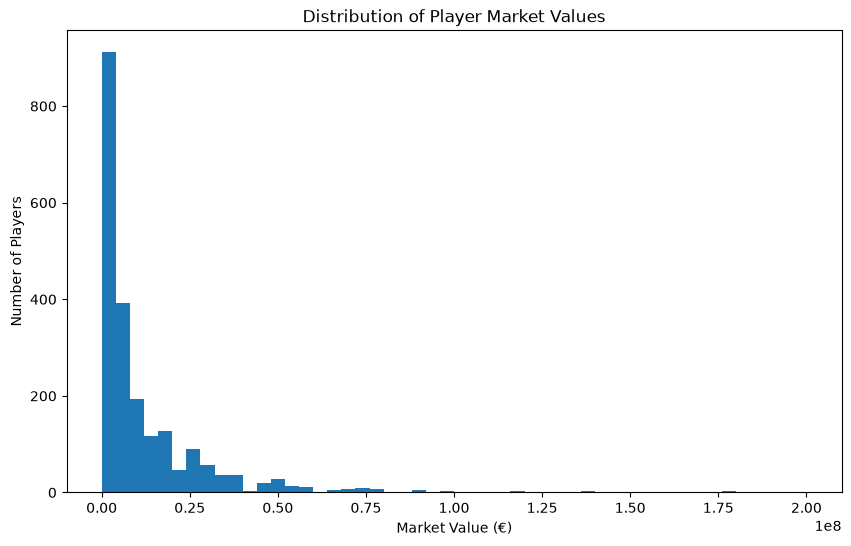

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    final_df["market_value_in_eur"],
    bins=50
)

plt.xlabel("Market Value (€)")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Market Values")

plt.show()

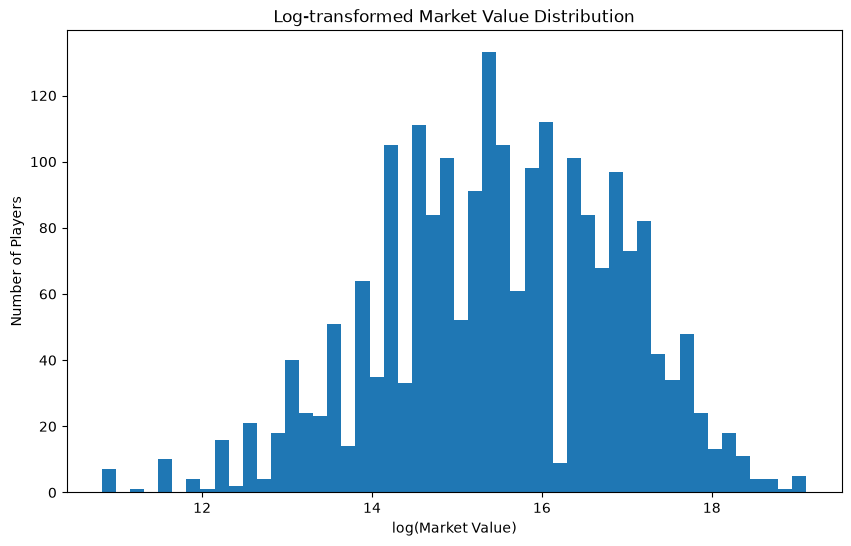

In [78]:
import numpy as np

final_df["log_market_value"] = np.log1p(
    final_df["market_value_in_eur"]
)
plt.figure(figsize=(10, 6))

plt.hist(
    final_df["log_market_value"],
    bins=50
)

plt.xlabel("log(Market Value)")
plt.ylabel("Number of Players")
plt.title("Log-transformed Market Value Distribution")

plt.show()